**Objective:**
To build a Decision Tree Classification model capable of identifying fraudulent banking transactions based on transaction details, customer behavior, account balance information,  risk score, and authentication patterns.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import files

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Read the Excel file
df = pd.read_csv('DecisionTree-XGBoost_dataset.csv')

# Step 3: Display data
df.head()

Saving DecisionTree-XGBoost_dataset.csv to DecisionTree-XGBoost_dataset.csv


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(50000, 21)

Columns:
Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label'],
      dtype='object')

Data Types:
Transaction_ID                   object
User_ID                          object
Transaction_Amount              float64
Transaction_Type                 object
Timestamp                        object
Account_Balance                 float64
Device_Type                      object
Location                         object
Merchant_Category                object
IP_Address_Flag                   int64
Previous_Fraudulent_Activity      int64
Daily_Transaction_Count      

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Timestamp,0
Account_Balance,0
Device_Type,0
Location,0
Merchant_Category,0
IP_Address_Flag,0


In [ ]:
df['Fraud_Label'].value_counts()

,count
Fraud_Label,
0,33933
1,16067


In [ ]:
df['Fraud_Label'].value_counts(normalize=True)*100

,proportion
Fraud_Label,
0,67.866
1,32.134


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

df.drop('Timestamp', axis=1, inplace=True)

df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,...,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label,Year,Month,Day,Hour
0,TXN_33553,USER_1834,39.79,POS,93213.17,Laptop,Sydney,Travel,0,0,...,65,883.17,Biometric,0.8494,0,0,2023,8,14,19
1,TXN_9427,USER_7875,1.19,Bank Transfer,75725.25,Mobile,New York,Clothing,0,0,...,186,2203.36,Password,0.0959,0,1,2023,6,7,4
2,TXN_199,USER_2734,28.96,Online,1588.96,Tablet,Mumbai,Restaurants,0,0,...,226,1909.29,Biometric,0.8400,0,1,2023,6,20,15
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,76807.20,Tablet,New York,Clothing,0,0,...,76,1311.86,OTP,0.7935,0,1,2023,12,7,0
4,TXN_39489,USER_2014,31.28,POS,92354.66,Mobile,Mumbai,Electronics,0,1,...,140,966.98,Password,0.3819,1,1,2023,11,11,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,TXN_11284,USER_4796,45.05,Online,76960.11,Mobile,Tokyo,Clothing,0,0,...,98,1537.54,PIN,0.1493,1,0,2023,1,29,18
49996,TXN_44732,USER_1171,126.15,POS,28791.75,Mobile,Tokyo,Clothing,0,0,...,93,2555.72,Biometric,0.3653,0,1,2023,5,9,8
49997,TXN_38158,USER_2510,72.02,Online,29916.41,Laptop,Mumbai,Clothing,0,1,...,114,4686.59,Biometric,0.5195,0,0,2023,1,30,19
49998,TXN_860,USER_2248,64.89,Bank Transfer,67895.67,Mobile,Tokyo,Electronics,0,0,...,72,4886.92,Biometric,0.7063,0,1,2023,3,9,19


In [ ]:
df.drop(
    ['Transaction_ID', 'User_ID'],
    axis=1,
    inplace=True
)

categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category',
       'Card_Type', 'Authentication_Method'],
      dtype='object')

In [ ]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Fraud_Label', axis=1)

y = df['Fraud_Label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

In [ ]:
criterion='gini'

max_depth=5

min_samples_split=20

min_samples_leaf=10

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred = dt_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy


Accuracy : 1.0


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[6787    0]
 [   0 3213]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6787
           1       1.00      1.00      1.00      3213

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
10,Failed_Transaction_Count_7d,0.525413
15,Risk_Score,0.474587
2,Account_Balance,0.000000
1,Transaction_Type,0.000000
0,Transaction_Amount,0.000000
4,Location,0.000000
3,Device_Type,0.000000
7,Previous_Fraudulent_Activity,0.000000
5,Merchant_Category,0.000000
8,Daily_Transaction_Count,0.000000


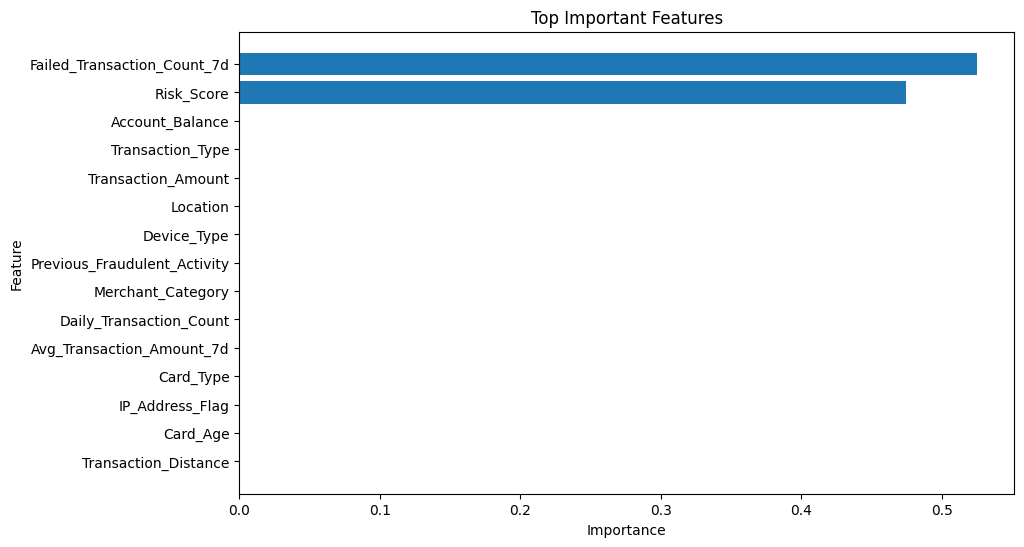

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top Important Features")

plt.show()

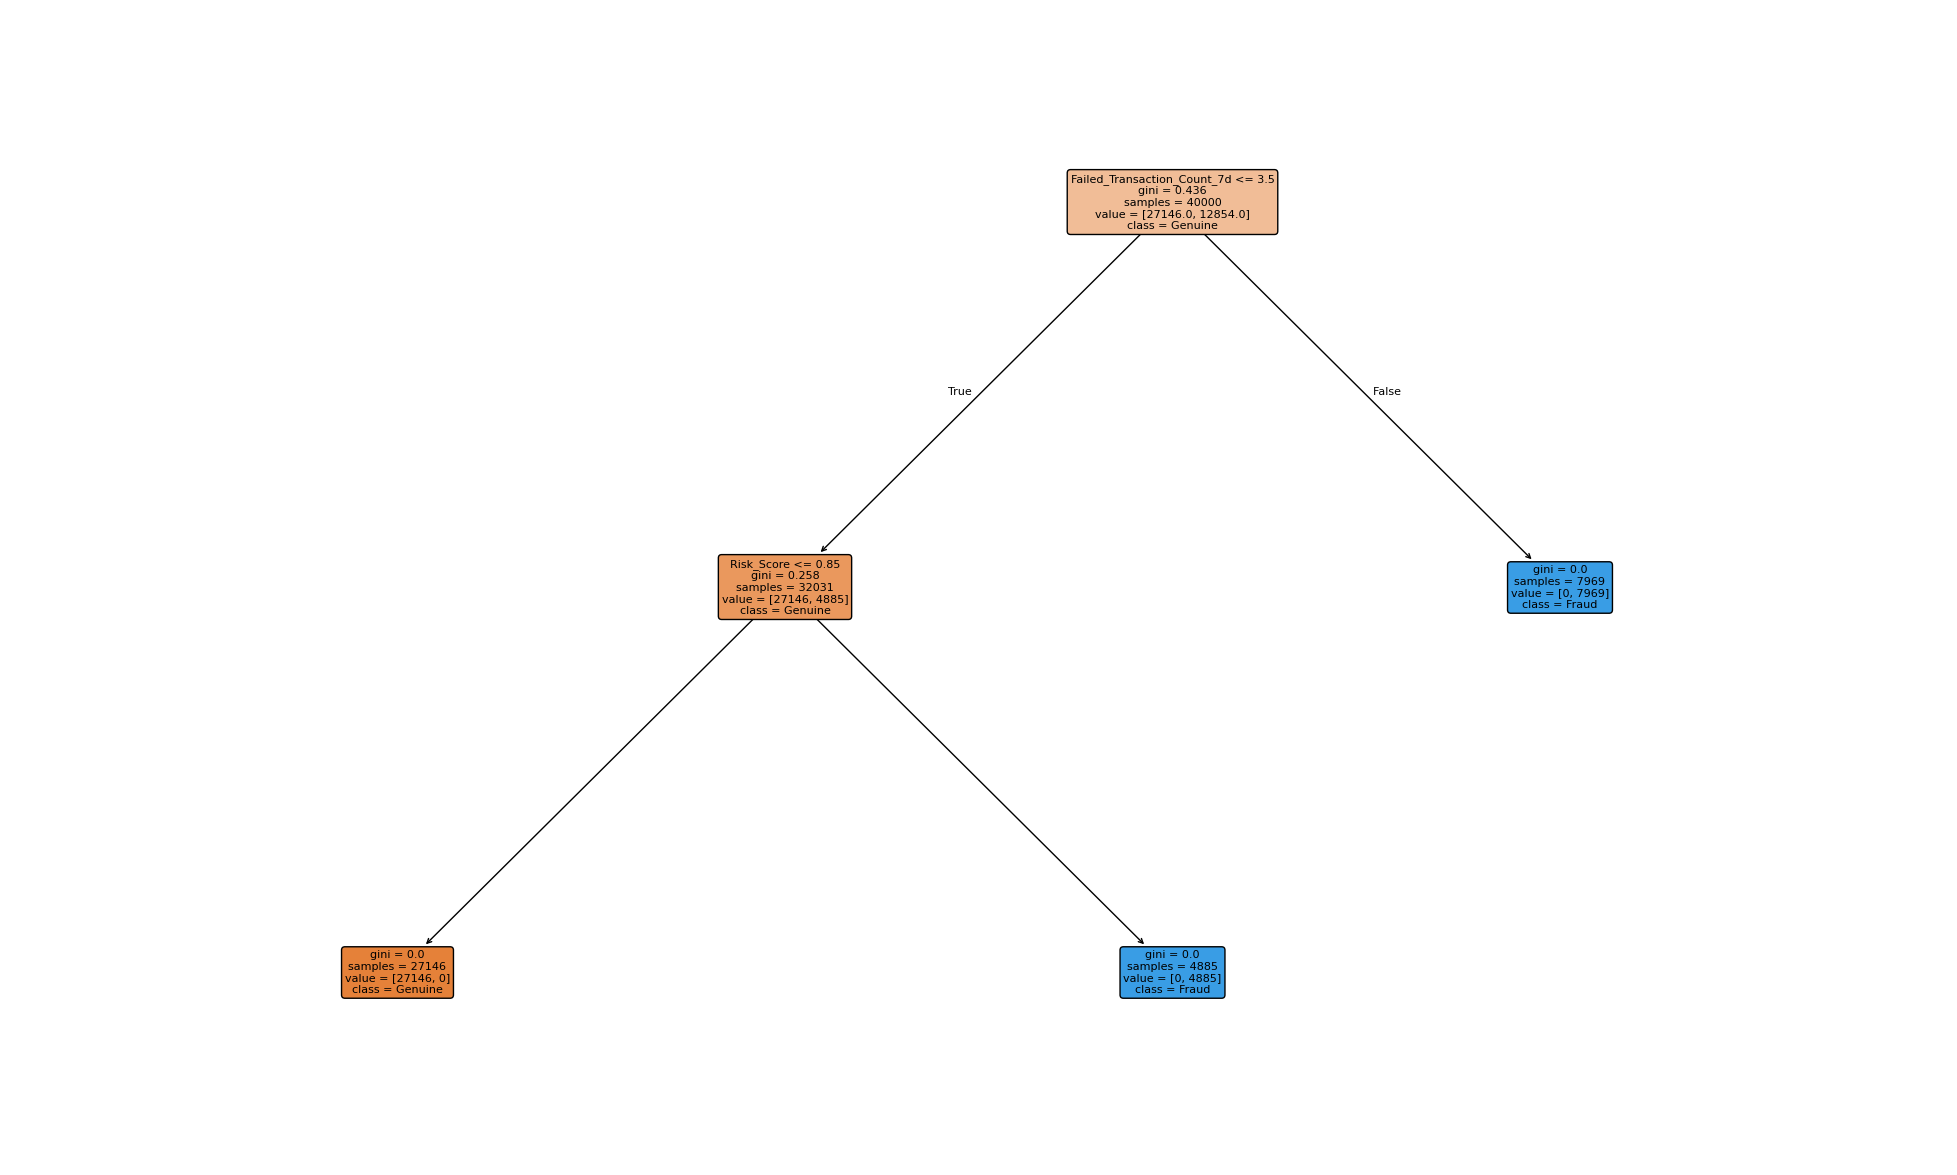

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,15))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Genuine','Fraud'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()